**Description Of the features of the dataset:**

Y – Latitude coordinate of the observation station.
X – Longitude coordinate of the observation station.
data_payload_id – Unique identifier for the data record.
instance_datetime – Timestamp when the data was recorded.
url – URL reference to the data source.
agency – Organization responsible for the data.
platform_type – Type of platform (e.g., station, balloon, etc.).
platform_id – Numeric ID for the platform.
platform_name – Name of the observation platform or station.
gaw_id – Global Atmosphere Watch ID of the platform.
instrument_name – Name of the instrument used for measurement.
instrument_model – Model of the instrument.
instrument_number – Instrument's identification number.
monthly_date – Date associated with monthly aggregated data.
monthly_columno3 – Monthly average ozone column value.
monthly_stddevo3 – Standard deviation of the monthly ozone values.
monthly_npts – Number of observations used in monthly average.
daily_date – Date of the daily observation.
daily_wlcode – Wavelength code used during observation.
daily_obscode – Observation code (e.g., method or technique).
daily_columno3 – Daily ozone column measurement (Dobson Units).
daily_stddevo3 – Standard deviation of the daily ozone value.
daily_utc_begin – UTC time when observation began.
daily_utc_end – UTC time when observation ended.
daily_utc_mean – Mean UTC time of observation.
daily_nobs – Number of observations for that day.
daily_mmu – Measurement uncertainty for daily ozone.
daily_columnso2 – Daily SO₂ (sulfur dioxide) column measurement.
latest_observation – Flag indicating if this is the most recent data (0 or 1).
country – Country of the observation station.
scientific_authority – Name of the responsible scientist or authority.
version – Version number of the data record.

In [1]:
%pip install optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.linear_model import ElasticNet

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import (
    HuberRegressor,
    TheilSenRegressor,
    PassiveAggressiveRegressor,
    OrthogonalMatchingPursuit,
    SGDRegressor,
    BayesianRidge,
    ARDRegression,
    PoissonRegressor,
    TweedieRegressor,
    GammaRegressor,
    LassoCV,
    RidgeCV,
    ElasticNetCV
    
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import optuna
from optuna.samplers import TPESampler



Note: you may need to restart the kernel to use updated packages.


c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_csv('result _2.csv')
df.head()


c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (19,30) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


,Y,X,data_payload_id,instance_datetime,url,agency,platform_type,platform_id,platform_name,gaw_id,...,daily_utc_begin,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,latest_observation,country,scientific_authority,version
0,43.781,-79.468,2260788,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.6,19.3,17.4,22.0,2.7,-6.7,0,CAN,Vitali Fioletov,4.15
1,43.781,-79.468,2260768,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.1,19.6,17.2,21.0,2.8,-4.9,0,CAN,Vitali Fioletov,4.15
2,43.781,-79.468,2260775,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.0,18.9,17.7,15.0,2.7,-3.3,0,CAN,Vitali Fioletov,4.15
3,43.781,-79.468,2260778,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,17.5,19.5,18.5,11.0,2.9,0.9,0,CAN,Vitali Fioletov,4.15
4,58.739,-94.074,2260790,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,77,Churchill,CHL,...,13.9,13.9,13.9,1.0,1.7,-3.5,0,CAN,Vitali Fioletov,4.16


In [3]:
df=df.drop(['Y', 'X', 'data_payload_id', 'instance_datetime', 'url', 'agency',
       'platform_type', 'platform_id', 'platform_name', 'gaw_id',
       'instrument_name', 'instrument_model', 'instrument_number',
       'monthly_date', 'monthly_stddevo3', 'monthly_npts','daily_stddevo3',
        'daily_wlcode', 'daily_obscode', 'monthly_columno3',
        'daily_utc_begin', 'daily_utc_end', 'daily_utc_mean',
       'daily_nobs', 'daily_mmu', 'daily_columnso2', 'latest_observation',
       'country', 'scientific_authority', 'version'], axis = 1)
df.head()

,daily_date,daily_columno3
0,2023-12-30,391.7
1,2023-12-10,345.1
2,2023-12-17,336.0
3,2023-12-20,341.5
4,2023-12-01,378.6


In [4]:
# df['daily_date'] = pd.to_datetime(df['daily_date'], format='%d-%m-%y')

# 2. Sort the dataframe by the full date (oldest to latest)
scaler = MinMaxScaler()
df['daily_columno3'] = scaler.fit_transform(df[['daily_columno3']])
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)

# Rolling average feature (7-day)
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
df['rolling_std'] = df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
df['ewm_avg'] = df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
df['ewm_std'] = df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 121):
  df[f'lag{i}'] = df['daily_columno3'].shift(i)

df.dropna(inplace=True)
print(df.shape)
df.head()


(192308, 126)


,daily_date,daily_columno3,rolling_avg,rolling_std,ewm_avg,ewm_std,lag1,lag2,lag3,lag4,...,lag111,lag112,lag113,lag114,lag115,lag116,lag117,lag118,lag119,lag120
120,1957-08-08,0.336129,0.352578,0.051380,0.351546,0.044934,0.316285,0.388093,0.372136,0.324264,...,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938,0.465835,0.405892
121,1957-08-08,0.324264,0.355953,0.048757,0.348743,0.041124,0.336129,0.316285,0.388093,0.372136,...,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938,0.465835
122,1957-08-08,0.399959,0.342594,0.033715,0.344292,0.038507,0.324264,0.336129,0.316285,0.388093,...,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938
123,1957-08-09,0.266367,0.353355,0.033063,0.354414,0.041538,0.399959,0.324264,0.336129,0.316285,...,0.425941,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023
124,1957-08-09,0.336129,0.345172,0.043088,0.338405,0.051894,0.266367,0.399959,0.324264,0.336129,...,0.378069,0.425941,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069


In [5]:

lag_features = [f'lag{i}' for i in range(1, 121)]
lag_features.append('rolling_avg')
lag_features.append('rolling_std')
lag_features.append('ewm_avg')
lag_features.append('ewm_std')
X= df[lag_features]
y = df['daily_columno3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.068
MAE : 0.051
R2  : 56.88 %

----- Decision Tree -----
RMSE: 0.095
MAE : 0.071
R2  : 14.87 %

----- Random Forest -----
RMSE: 0.068
MAE : 0.051
R2  : 56.28 %

----- Gradient Boosting -----
RMSE: 0.068
MAE : 0.051
R2  : 56.73 %

----- Support Vector Regressor -----
RMSE: 0.072
MAE : 0.054
R2  : 51.24 %

----- AdaBoost Regressor -----
RMSE: 0.082
MAE : 0.066
R2  : 37.17 %

----- MLP Regressor -----
RMSE: 0.068
MAE : 0.051
R2  : 56.94 %

----- K-Neighbors Regressor -----
RMSE: 0.074
MAE : 0.056
R2  : 48.43 %



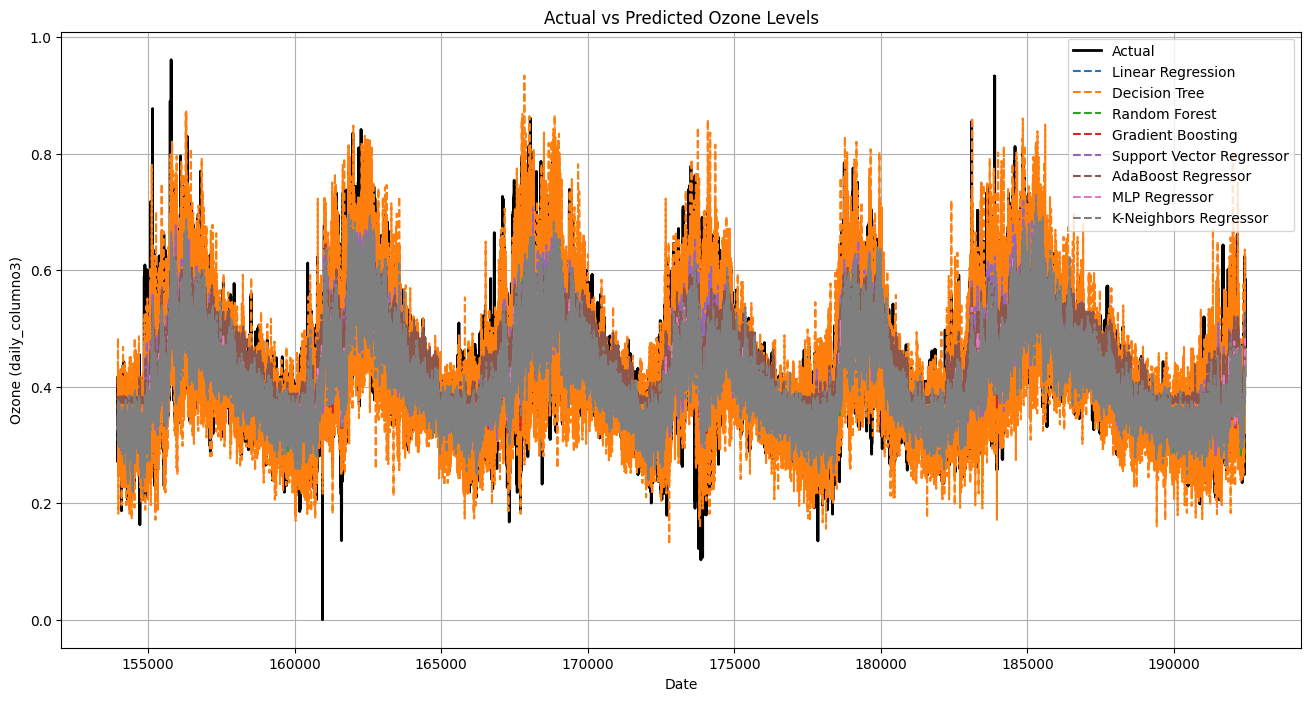

In [ ]:


# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    'AdaBoost Regressor': AdaBoostRegressor(n_estimators=50, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42),
    'K-Neighbors Regressor': KNeighborsRegressor(n_neighbors=3)
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training ridge...
Training Extra Trees Regressor...
Model Evaluation Metrics:

----- ridge -----
RMSE: 0.068
MAE : 0.051
R2  : 56.88 %

----- Extra Trees Regressor -----
RMSE: 0.068
MAE : 0.051
R2  : 56.32 %



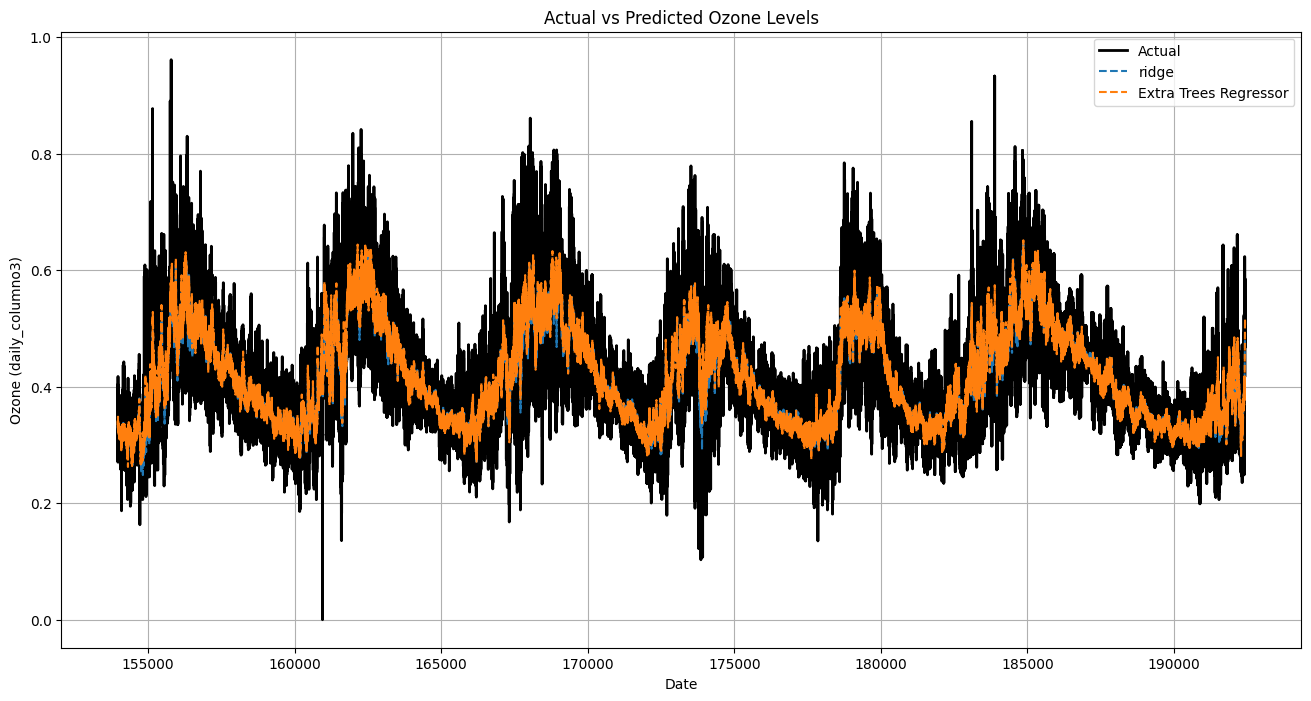

In [ ]:


# STEP 3: Define models
models = {
    'ridge': Ridge(alpha=1.0, random_state=42),
    'Extra Trees Regressor': ExtraTreesRegressor(n_estimators=100, random_state=42),

}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training ElasticNet...
Training Hist Gradient Boosting...
Training Voting Regressor...
Model Evaluation Metrics:

----- ElasticNet -----
RMSE: 0.104
MAE : 0.085
R2  : -2.16 %

----- Hist Gradient Boosting -----
RMSE: 0.068
MAE : 0.051
R2  : 56.76 %

----- Voting Regressor -----
RMSE: 0.068
MAE : 0.051
R2  : 56.91 %



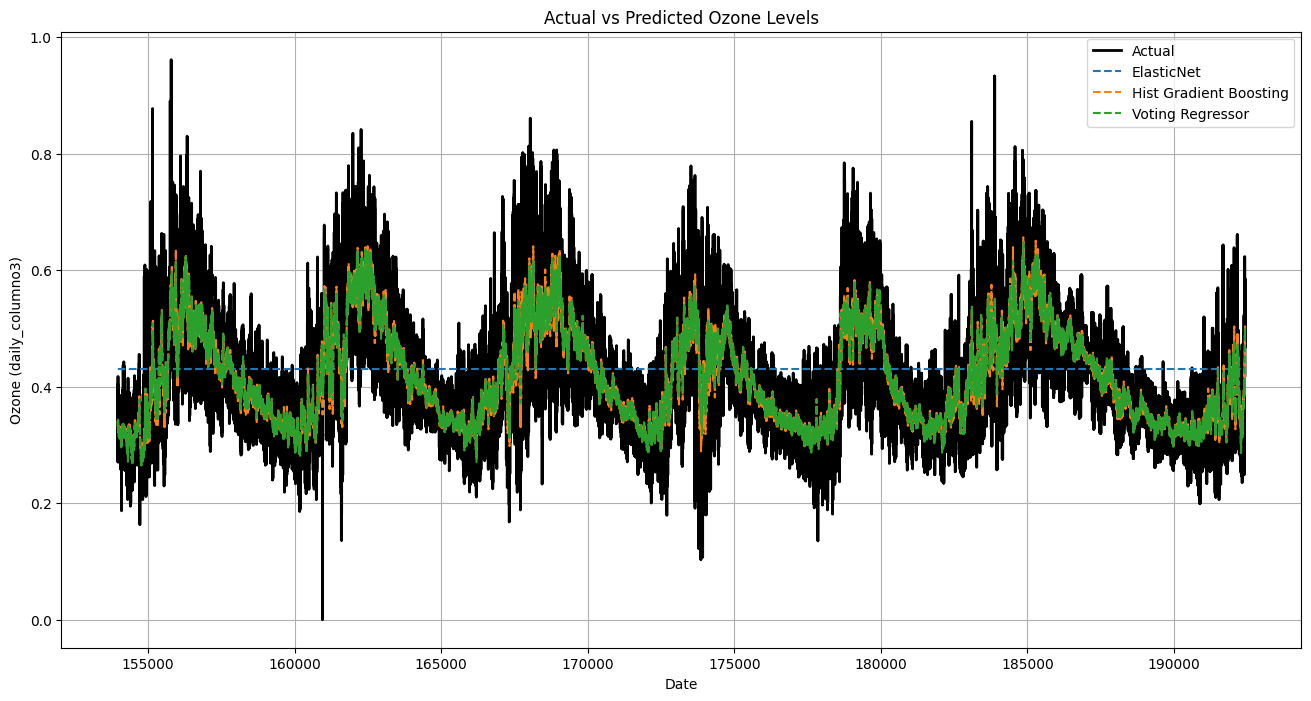

In [ ]:


# STEP 3: Define models
models = {
    'Hist Gradient Boosting': HistGradientBoostingRegressor(max_iter=100, random_state=42),
    'Voting Regressor': VotingRegressor(estimators=[
        ('ridge', Ridge(alpha=1.0, random_state=42)),
        ('Extra Trees Regressor', ExtraTreesRegressor(n_estimators=100, random_state=42))
    ]),
 

}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training StackingRegressor...
Model Evaluation Metrics:

----- StackingRegressor -----
RMSE: 0.068
MAE : 0.051
R2  : 56.86 %



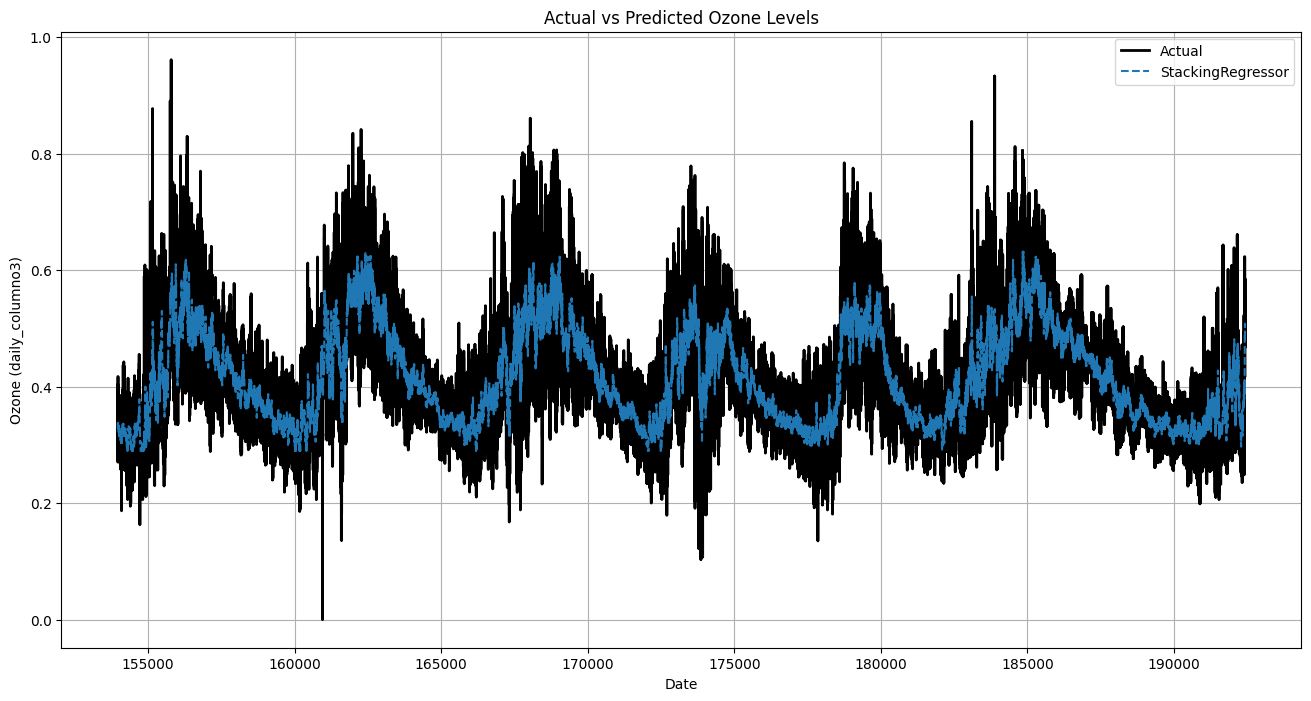

In [ ]:


# STEP 3: Define models
models = {
    'StackingRegressor': StackingRegressor(
        estimators=[                  
            ('ridge', Ridge(alpha=1.0, random_state=42)),
            ('Extra Trees Regressor', ExtraTreesRegressor(n_estimators=100, random_state=42))
        ],
        final_estimator=HistGradientBoostingRegressor(max_iter=100, random_state=42)
    ),
 

}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training HuberRegressor...


c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\sklearn\linear_model\_huber.py:332: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Model Evaluation Metrics:

----- HuberRegressor -----
RMSE: 0.068
MAE : 0.051
R2  : 56.76 %



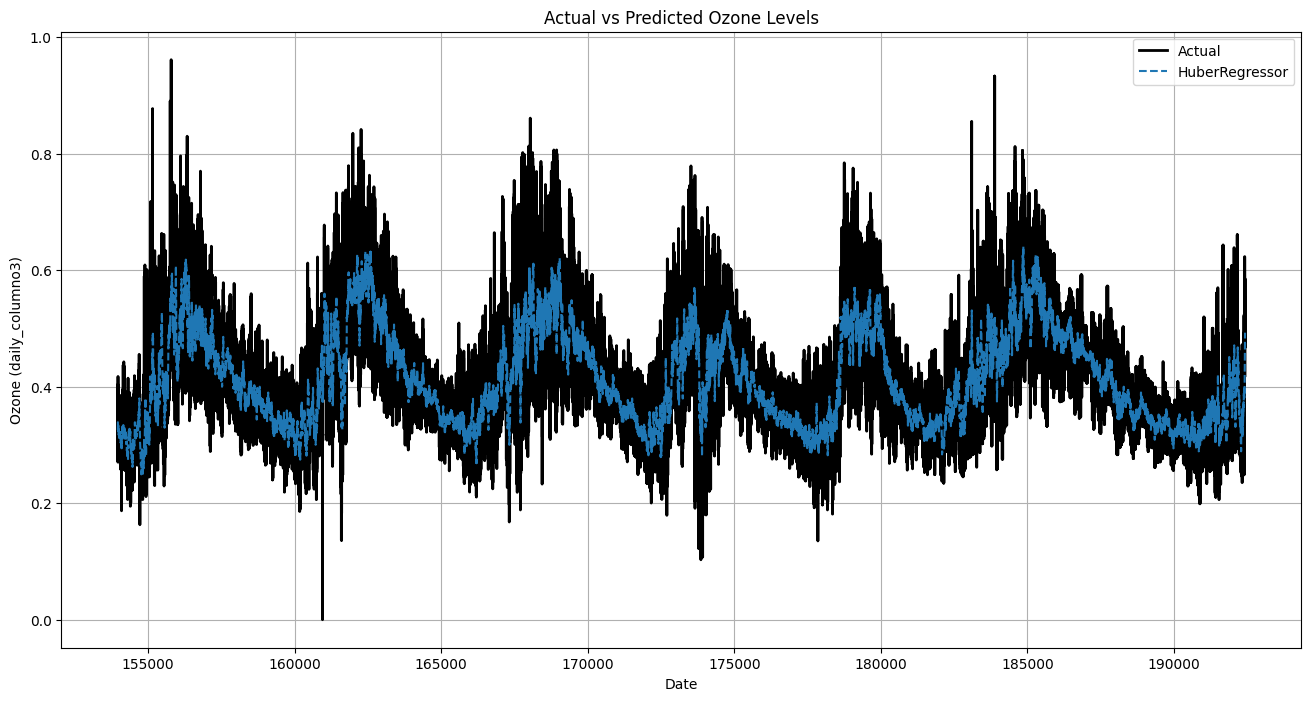

In [ ]:


# STEP 3: Define models
models = {
    'HuberRegressor': HuberRegressor(),
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training TheilSenRegressor...


c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\sklearn\linear_model\_theil_sen.py:131: ConvergenceWarning: Maximum number of iterations 300 reached in spatial median for TheilSen regressor.
  ConvergenceWarning,


Model Evaluation Metrics:

----- TheilSenRegressor -----
RMSE: 0.147
MAE : 0.109
R2  : -104.11 %



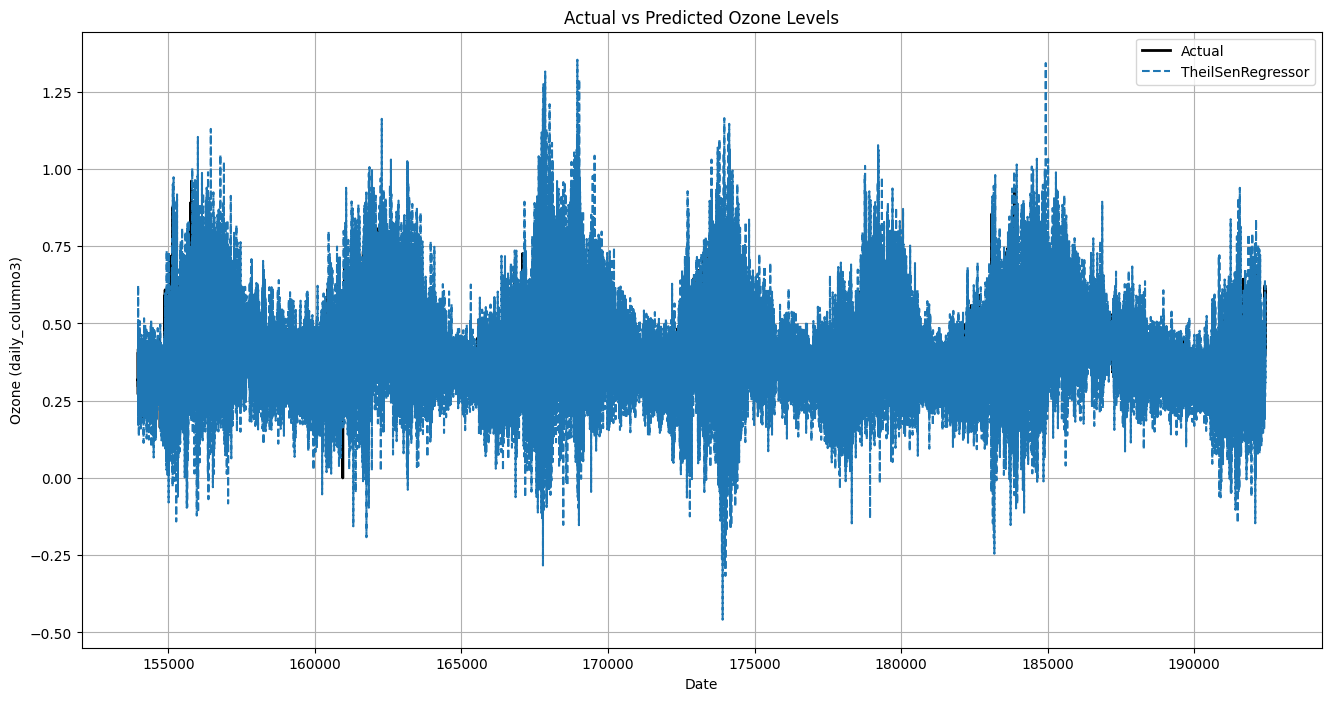

In [ ]:


# STEP 3: Define models
models = {
    'TheilSenRegressor': TheilSenRegressor(),
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training PassiveAggressiveRegressor...
Model Evaluation Metrics:

----- PassiveAggressiveRegressor -----
RMSE: 0.074
MAE : 0.057
R2  : 48.65 %



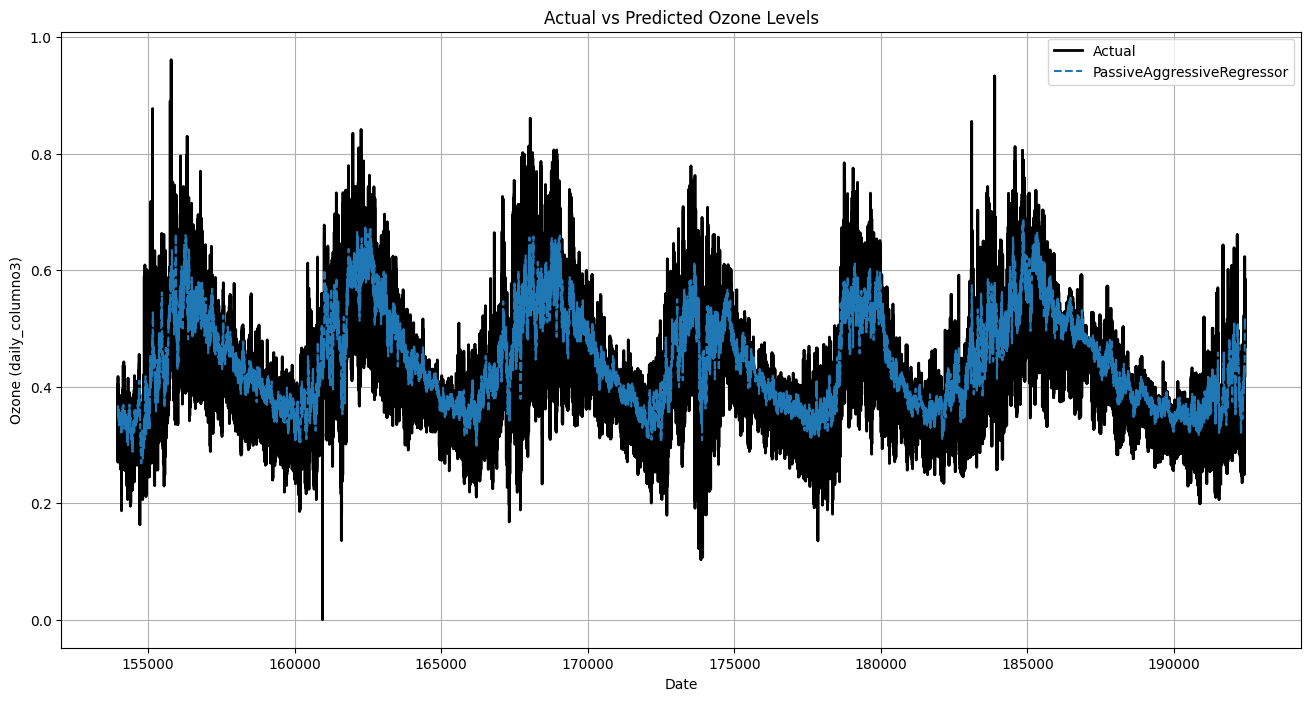

In [ ]:


# STEP 3: Define models
models = {
    'PassiveAggressiveRegressor': PassiveAggressiveRegressor(),


}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training OrthogonalMatchingPursuit...


c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\sklearn\linear_model\_base.py:138: FutureWarning: The default of 'normalize' will be set to False in version 1.2 and deprecated in version 1.4.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), OrthogonalMatchingPursuit())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)


  FutureWarning,


Model Evaluation Metrics:

----- OrthogonalMatchingPursuit -----
RMSE: 0.068
MAE : 0.051
R2  : 56.71 %



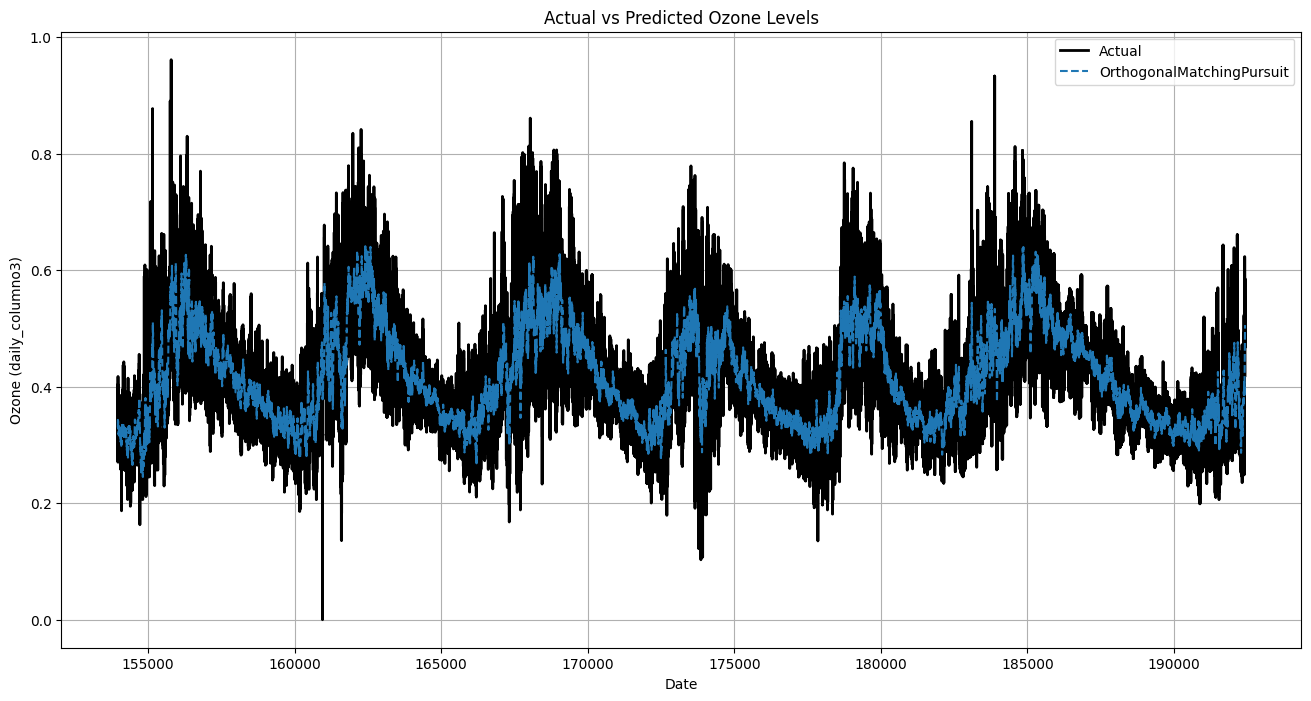

In [ ]:


# STEP 3: Define models
models = {
    'OrthogonalMatchingPursuit': OrthogonalMatchingPursuit(),
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training SGDRegressor...
Model Evaluation Metrics:

----- SGDRegressor -----
RMSE: 0.068
MAE : 0.051
R2  : 56.99 %



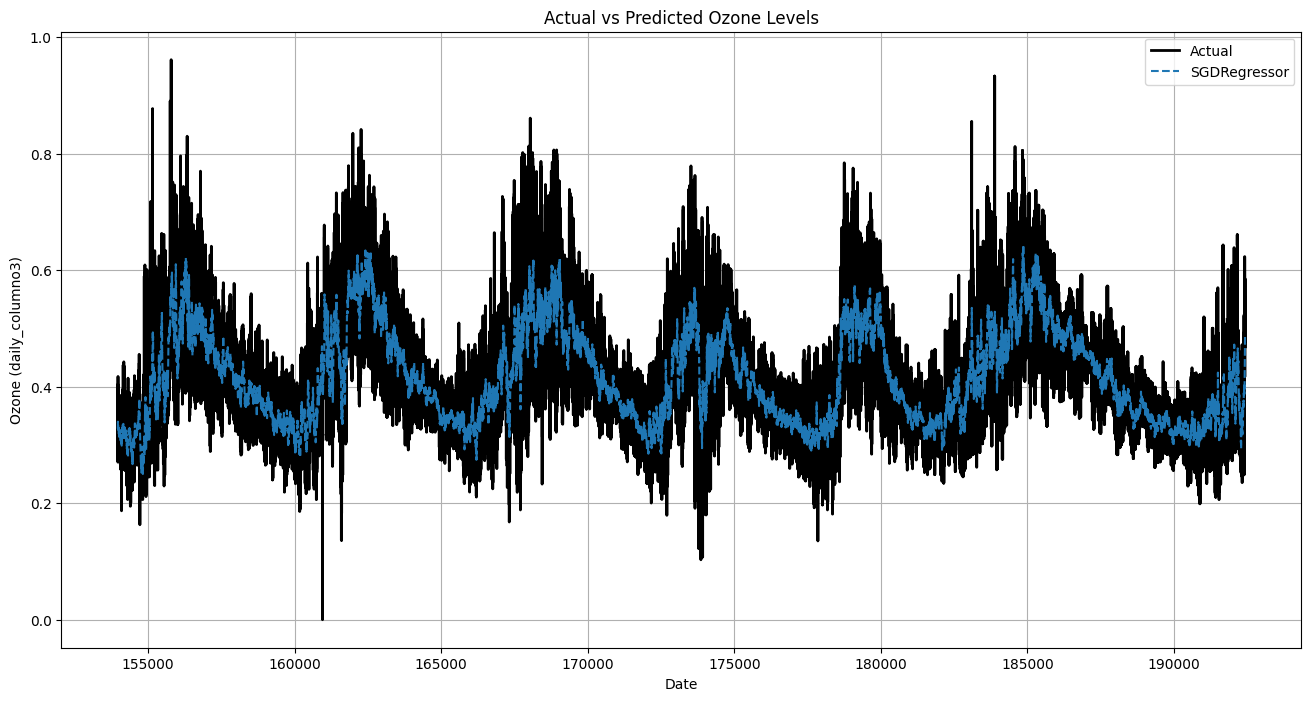

In [ ]:


# STEP 3: Define models
models = {
    'SGDRegressor': SGDRegressor(max_iter=1000, tol=1e-3),

}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training BayesianRidge...
Model Evaluation Metrics:

----- BayesianRidge -----
RMSE: 0.068
MAE : 0.051
R2  : 56.90 %



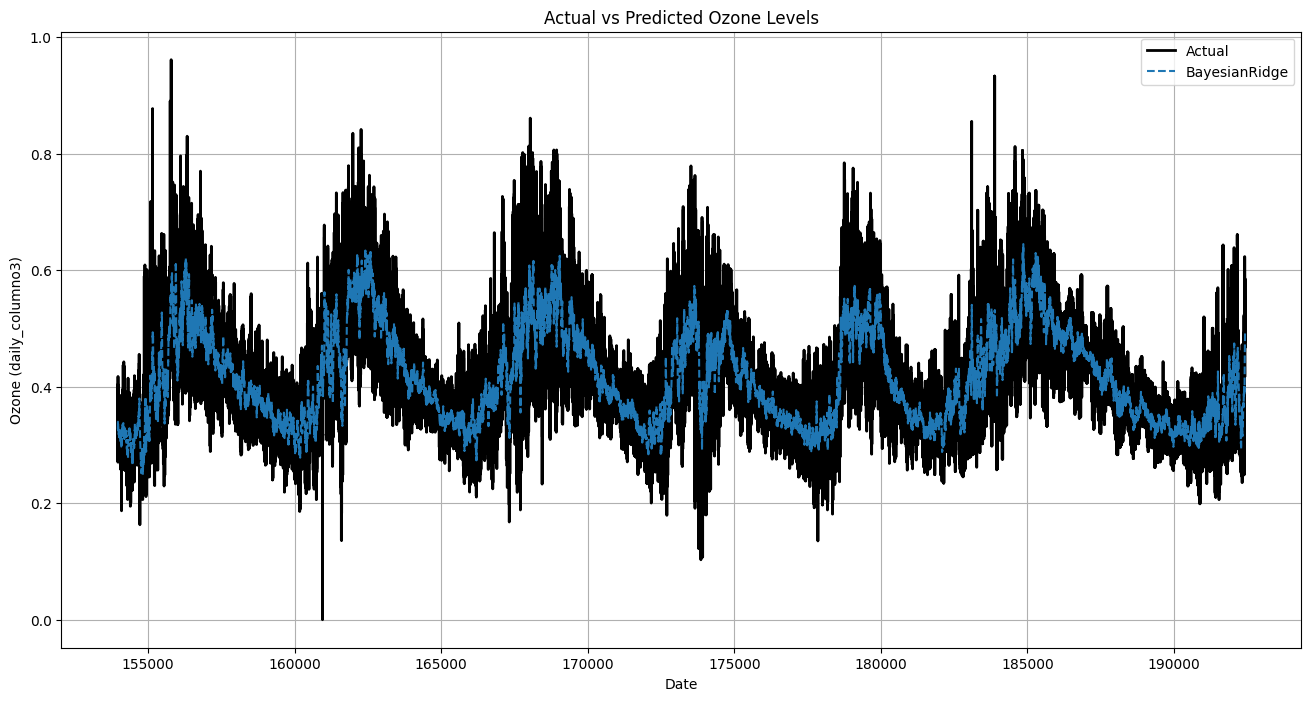

In [ ]:


# STEP 3: Define models
models = {
    'BayesianRidge': BayesianRidge(),
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training ARDRegression...
Model Evaluation Metrics:

----- ARDRegression -----
RMSE: 0.068
MAE : 0.051
R2  : 56.71 %



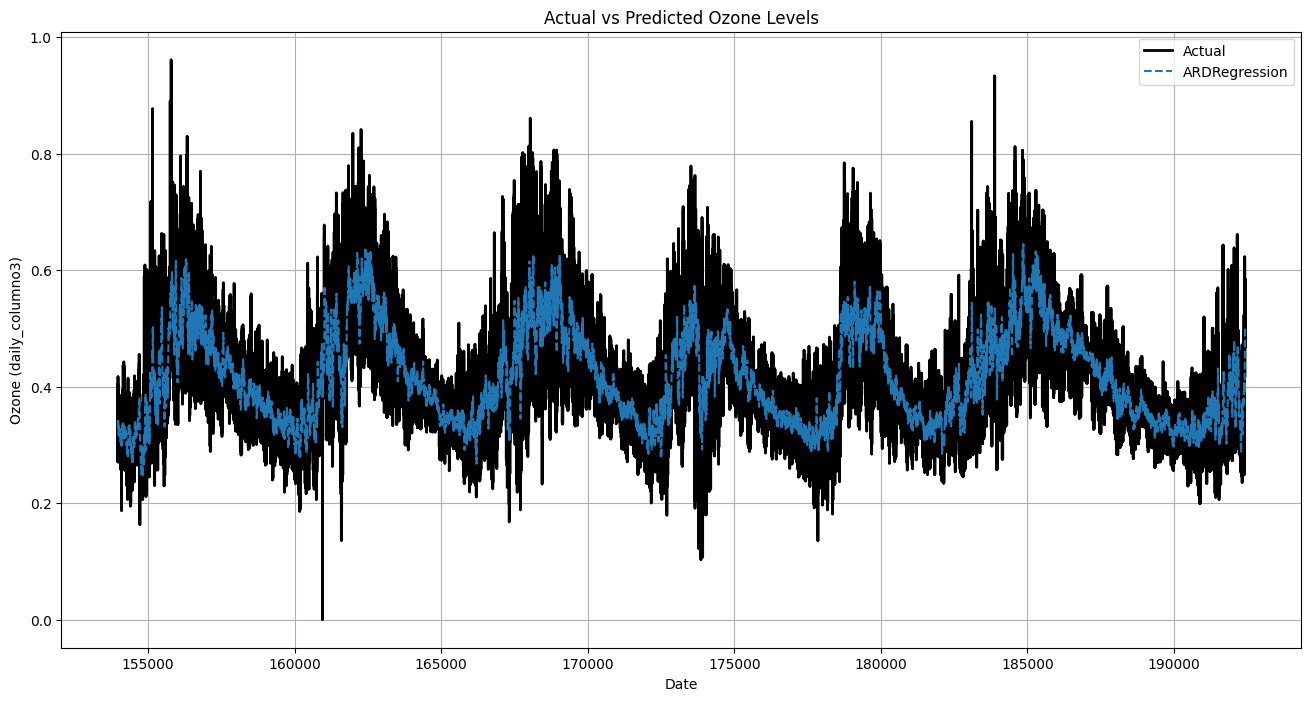

In [ ]:


# STEP 3: Define models
models = {
    'ARDRegression': ARDRegression(),
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training PoissonRegressor...
Model Evaluation Metrics:

----- PoissonRegressor -----
RMSE: 0.091
MAE : 0.073
R2  : 22.50 %



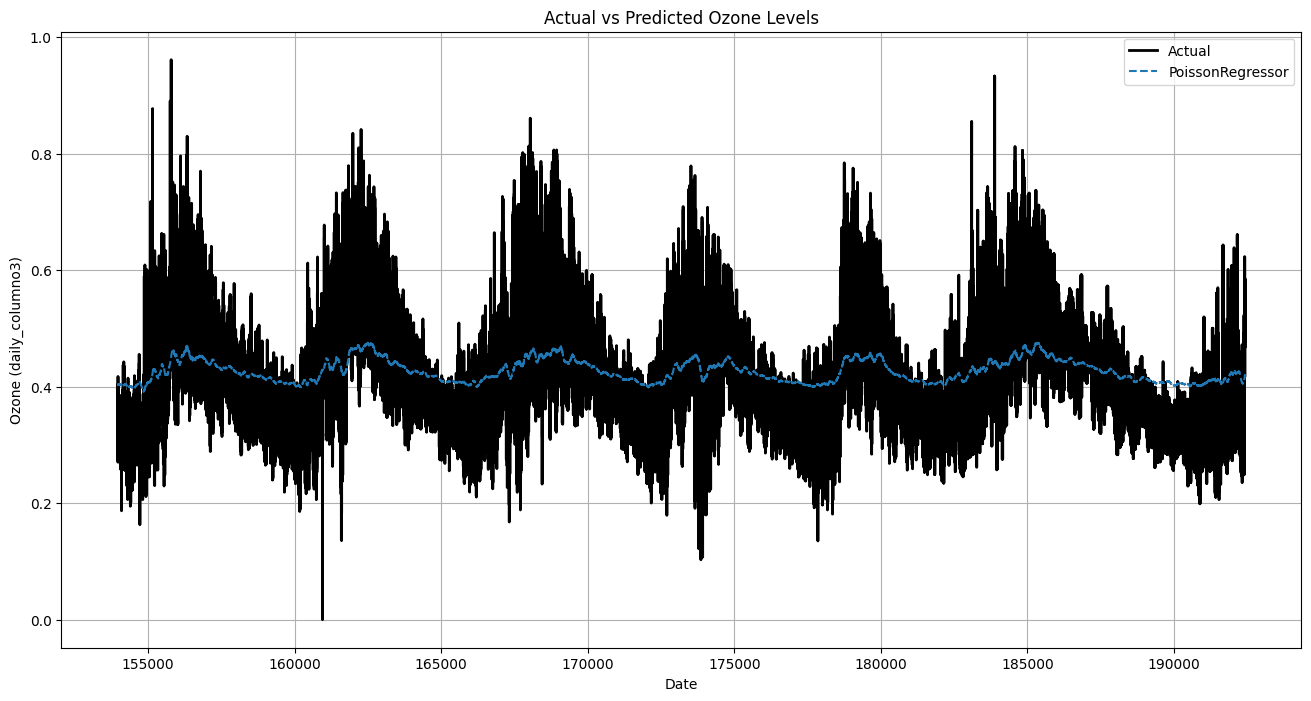

In [ ]:


# STEP 3: Define models
models = {
    'PoissonRegressor': PoissonRegressor(),
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training TweedieRegressor...
Model Evaluation Metrics:

----- TweedieRegressor -----
RMSE: 0.082
MAE : 0.065
R2  : 36.31 %



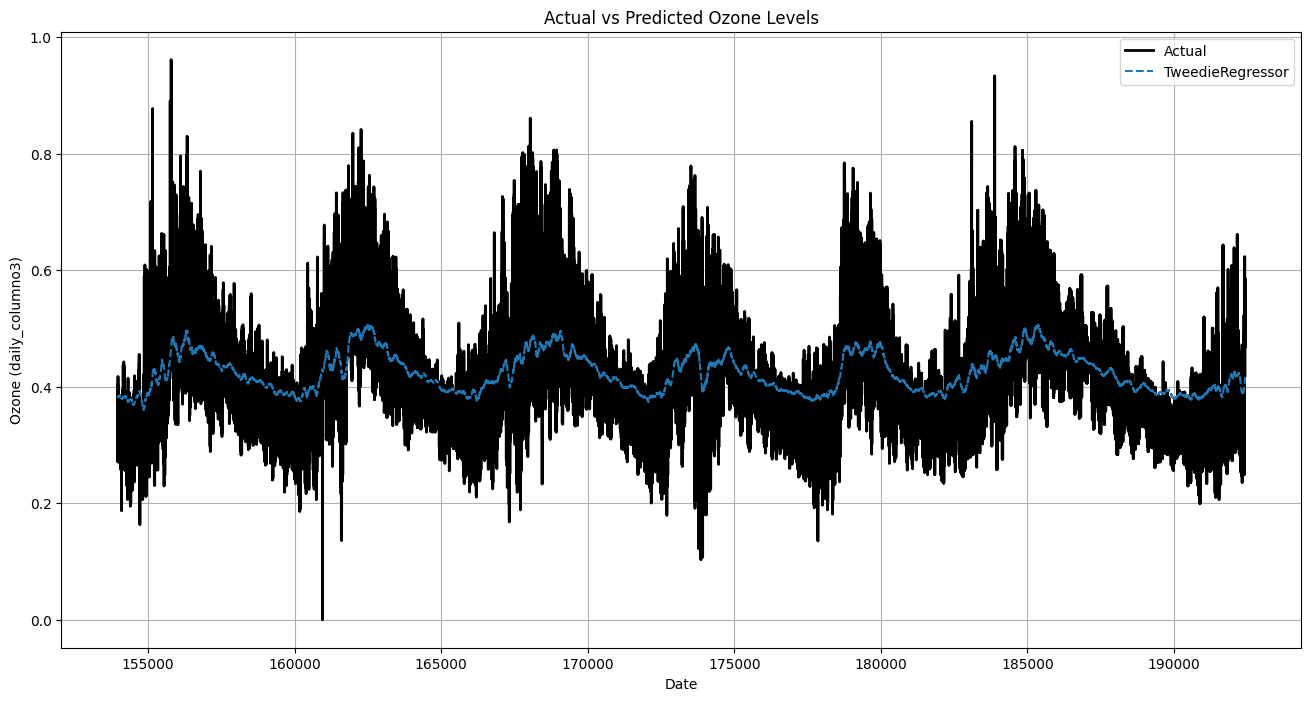

In [ ]:


# STEP 3: Define models
models = {
    'TweedieRegressor': TweedieRegressor(),

}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training GammaRegressor...
Model Evaluation Metrics:

----- GammaRegressor -----
RMSE: 0.082
MAE : 0.065
R2  : 36.22 %



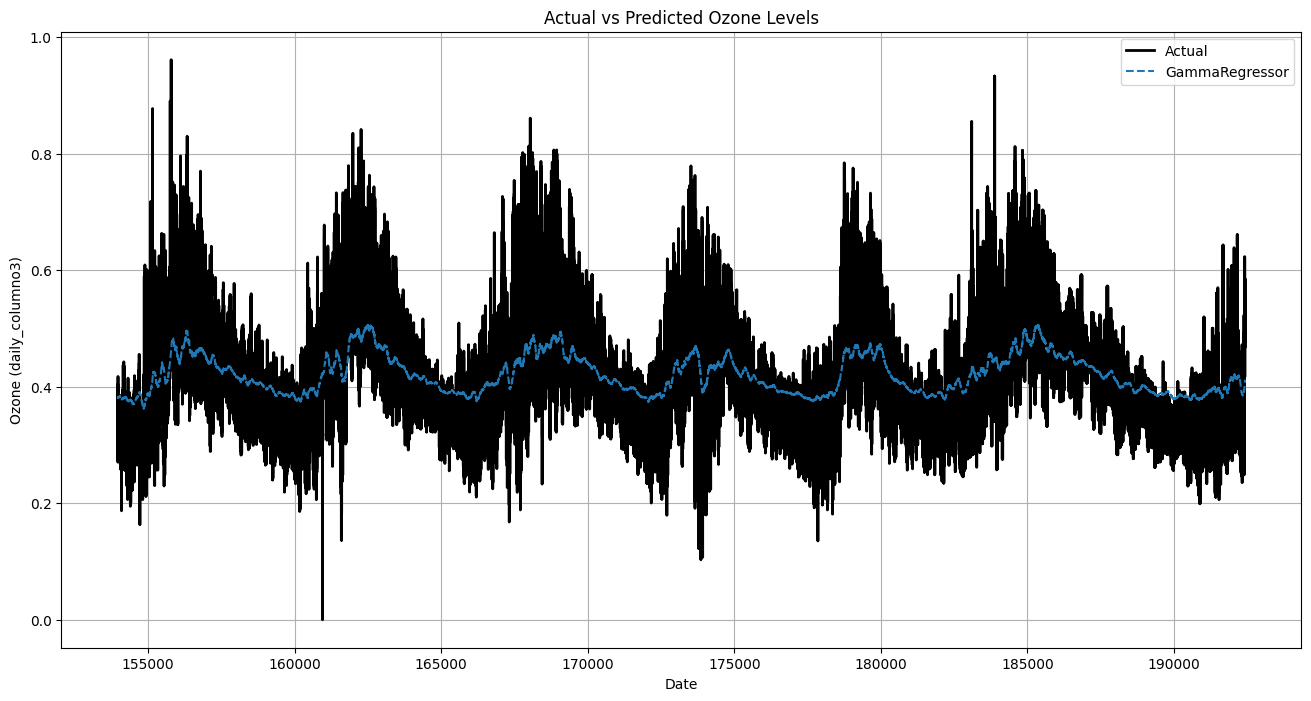

In [ ]:


# STEP 3: Define models
models = {
    'GammaRegressor': GammaRegressor(),

}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training LassoCV...
Model Evaluation Metrics:

----- LassoCV -----
RMSE: 0.068
MAE : 0.051
R2  : 56.90 %



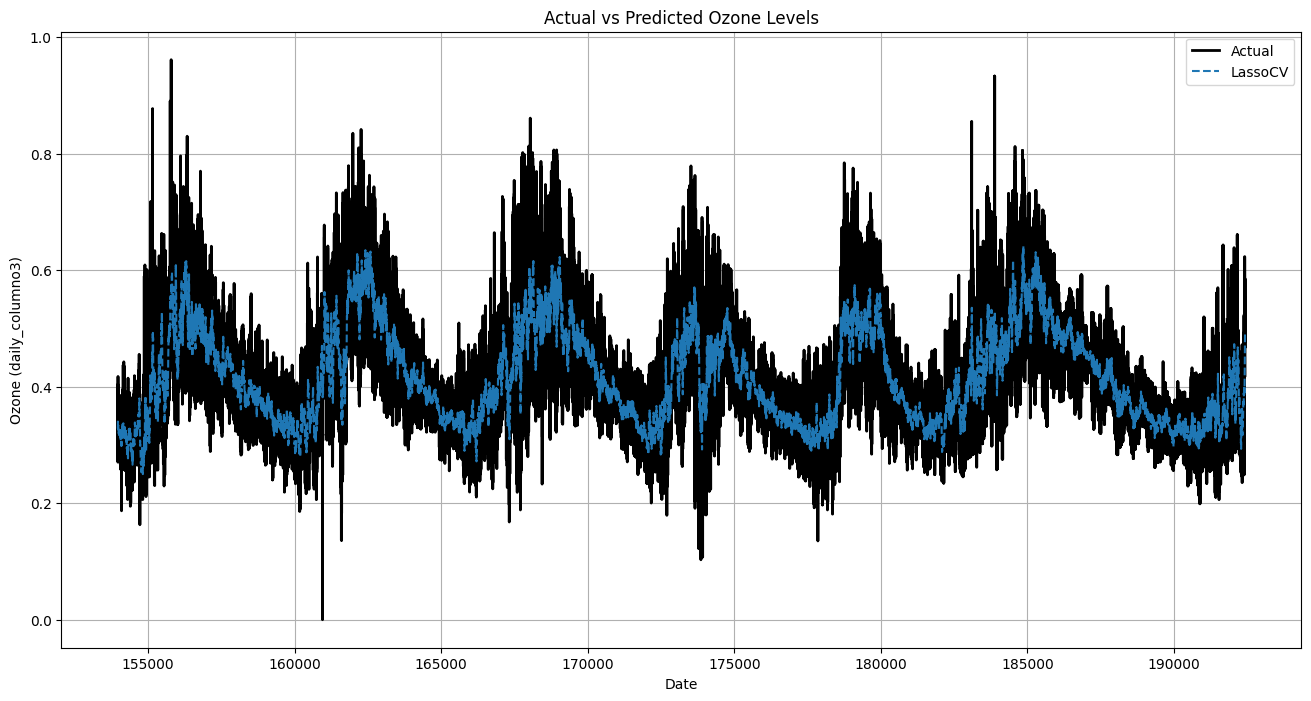

In [ ]:


# STEP 3: Define models
models = {
    'LassoCV': LassoCV(cv=5),
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training RidgeCV...
Model Evaluation Metrics:

----- RidgeCV -----
RMSE: 0.068
MAE : 0.051
R2  : 56.89 %



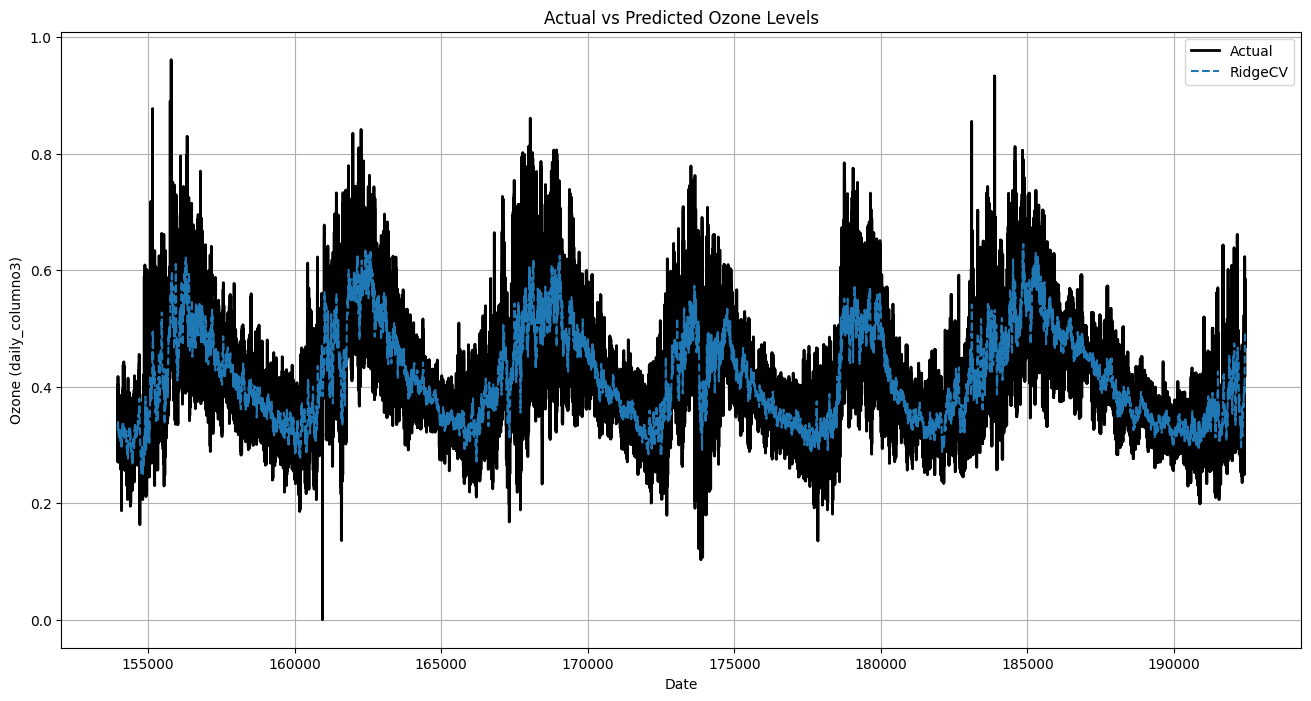

In [ ]:


# STEP 3: Define models
models = {
    'RidgeCV': RidgeCV(cv=5),

}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training ElasticNetCV...
Model Evaluation Metrics:

----- ElasticNetCV -----
RMSE: 0.068
MAE : 0.051
R2  : 56.90 %



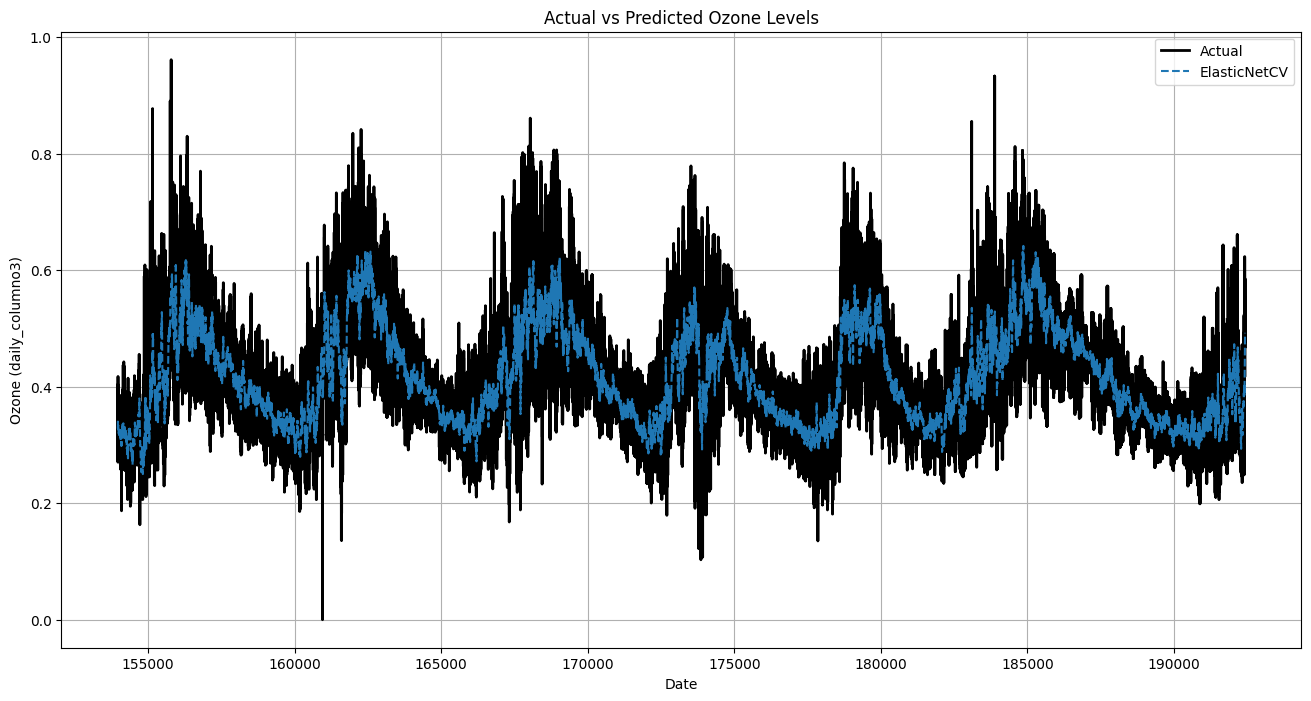

In [ ]:


# STEP 3: Define models
models = {
    'ElasticNetCV': ElasticNetCV(cv=5)

}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training StackingRegressor...
Model Evaluation Metrics:

----- StackingRegressor -----
RMSE: 0.068
MAE : 0.051
R2  : 56.91 %



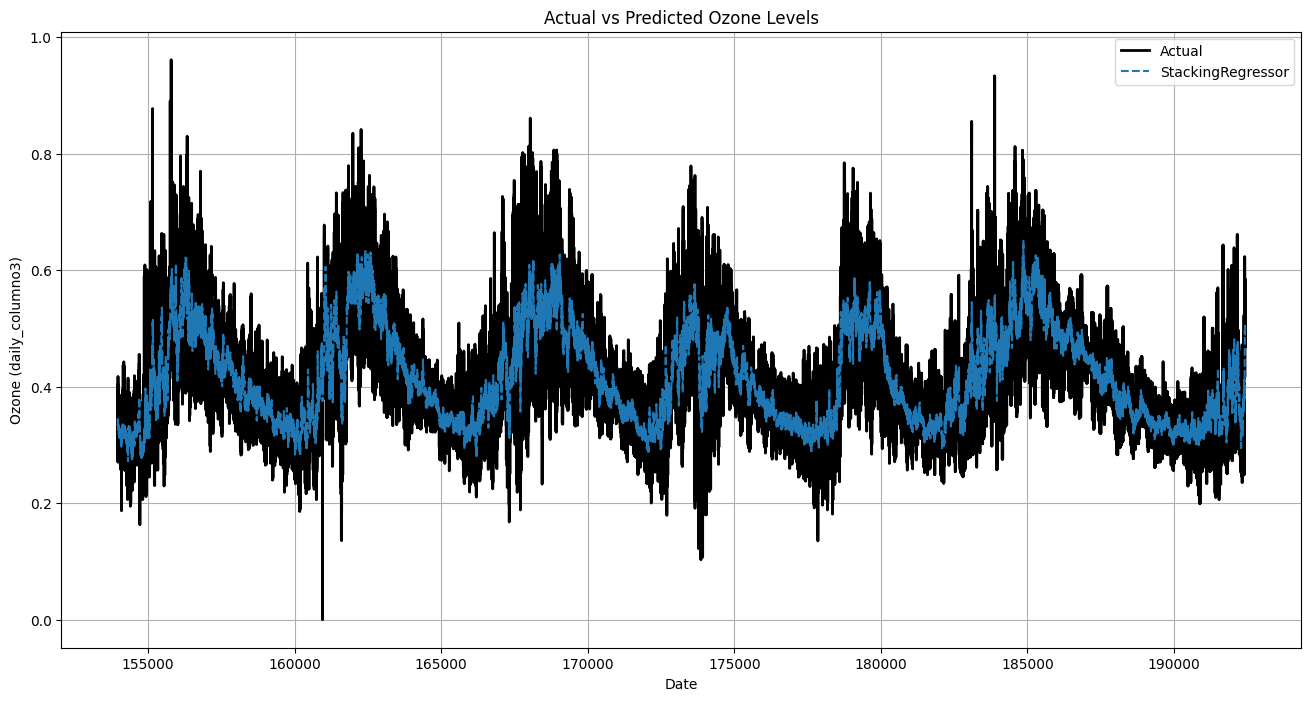

In [12]:


# STEP 3: Define models
models = {
    'StackingRegressor': StackingRegressor(
        estimators=[ 
            ('Extra Trees Regressor', ExtraTreesRegressor(n_estimators=100, random_state=42)),
            ('Random Forest Regressor', RandomForestRegressor(n_estimators=100, random_state=42)),
            ('Decision Tree Regressor', DecisionTreeRegressor(random_state=42)),
            ('KNeighbors Regressor', KNeighborsRegressor(n_neighbors=5)),
            ('AdaBoost Regressor', AdaBoostRegressor(n_estimators=100, random_state=42)),      
            ('Gradient Boosting Regressor', GradientBoostingRegressor(n_estimators=100, random_state=42)),
            ('XGBoost Regressor', XGBRegressor(n_estimators=100, random_state=42)),         
        ],
        final_estimator=LinearRegression(),
    ),

}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))



# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()